# **Load the preprocessed dataset**

In [65]:
import pandas as pd

df = pd.read_csv("Preprocessed_dataset.csv", delimiter=',')
print("Shape:", df.shape)
df.head()

Shape: (22991, 40)


/tmp/ipython-input-2777889780.py:3: DtypeWarning: Columns (34,35,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Preprocessed_dataset.csv", delimiter=',')


,age,fnlwgt,educational-num,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,...,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed
0,0.109589,226802,7,Machine-op-inspct,Own-child,Black,1,0.000000,0.0,0.397959,...,False,False,False,False,False,False,False,True,False,False
1,0.287671,89814,9,Farming-fishing,Husband,White,1,0.000000,0.0,0.500000,...,False,False,False,False,False,True,False,False,False,False
2,0.150685,336951,12,Protective-serv,Husband,White,1,0.000000,0.0,0.397959,...,False,False,False,False,False,True,False,False,False,False
3,0.369863,160323,10,Machine-op-inspct,Husband,Black,1,0.076881,0.0,0.397959,...,False,False,False,True,False,True,False,False,False,False
4,0.013699,103497,10,Prof-specialty,Own-child,White,0,0.000000,0.0,0.295918,...,False,False,False,True,False,False,False,True,False,False


# **Identify features (X) and target (y)**

In [66]:
# Robust target detection
target_col = "income" # Directly specify the target column name

# Print column names to diagnose
print("Columns in dataframe:", df.columns.tolist())

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")


print("Detected target column:", target_col)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Map strings to numeric if needed
if y.dtype == object:
    y = y.astype(str).str.strip()
    if set(y.unique()) <= {">50K", "<=50K"}:
        y = y.map({"<=50K": 0, ">50K": 1})
    elif set(y.unique()) <= {"1", "0"}:
        y = y.astype(int)
    else:
        # Generic factorize for unseen labels
        y, _ = pd.factorize(y)

print("y classes:", sorted(pd.Series(y).unique()))
print("Feature count:", X.shape[1])

Columns in dataframe: ['age', 'fnlwgt', 'educational-num', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed']
Detected target column: income
y classes: [np.int64(0), np.int64(1)]
Feature count: 39


# **Train/Test splits + Gini Decision Tree**

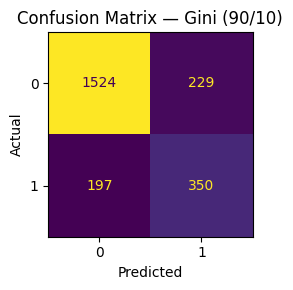

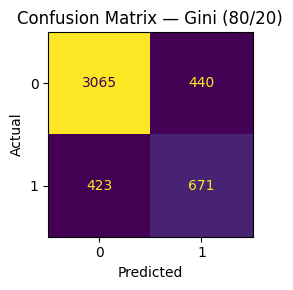

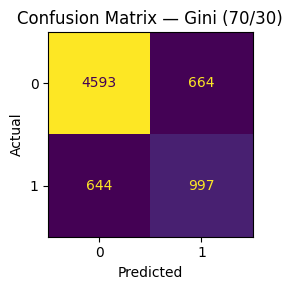

[('90/10',
  0.8147826086956522,
  0.8186927466681256,
  0.8147826086956522,
  0.8165614271799116),
 ('80/20',
  0.8123505109806479,
  0.813366173811496,
  0.8123505109806479,
  0.8128457881758289),
 ('70/30',
  0.8103798202377501,
  0.8111823369513415,
  0.8103798202377501,
  0.810773384906543)]

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# One-hot encode categorical features
X_encoded = pd.get_dummies(X)

splits = [(0.1, "90/10"), (0.2, "80/20"), (0.3, "70/30")]
results_gini = []
trained_models = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=test_size, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Store the trained model and test/prediction data
    trained_models[label] = (clf, X_test, y_test, y_pred)


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results_gini.append((label, acc, prec, rec, f1))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(4,3))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — Gini ({label})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

results_gini

# **Results table (Accuracy, Precision, Recall, F1)**

In [68]:
import pandas as pd

results_df = pd.DataFrame(results_gini, columns=["Split", "Accuracy", "Precision", "Recall", "F1-Score"])
order = {"90/10":0, "80/20":1, "70/30":2}
results_df["order"] = results_df["Split"].map(order)
results_df = results_df.sort_values("order").drop(columns="order").reset_index(drop=True)
results_df

,Split,Accuracy,Precision,Recall,F1-Score
0,90/10,0.814783,0.818693,0.814783,0.816561
1,80/20,0.812351,0.813366,0.812351,0.812846
2,70/30,0.810380,0.811182,0.810380,0.810773


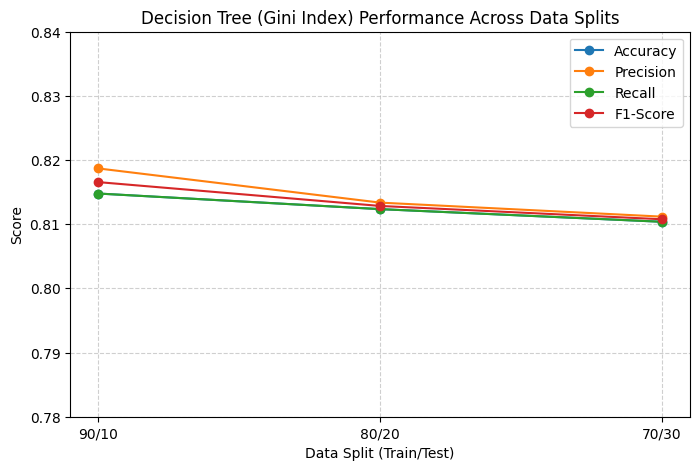

In [69]:
import matplotlib.pyplot as plt

# Plotting the comparison
plt.figure(figsize=(8,5))
plt.plot(results_df["Split"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Split"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Split"], results_df["Recall"], marker='o', label="Recall")
plt.plot(results_df["Split"], results_df["F1-Score"], marker='o', label="F1-Score")

plt.title("Decision Tree (Gini Index) Performance Across Data Splits")
plt.xlabel("Data Split (Train/Test)")
plt.ylabel("Score")
plt.ylim(0.78, 0.84)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

- The plot shows a slight decrease in all metrics as the test size increases, which is consistent with expectations — less training data typically reduces model accuracy.
- The small performance gap between the splits demonstrates good model stability and generalization.
- The overlapping metric curves (Accuracy ≈ Precision ≈ Recall ≈ F1) further confirm that the model’s predictions are balanced and consistent across both classes.

# **Visualize decision trees (Gini)**

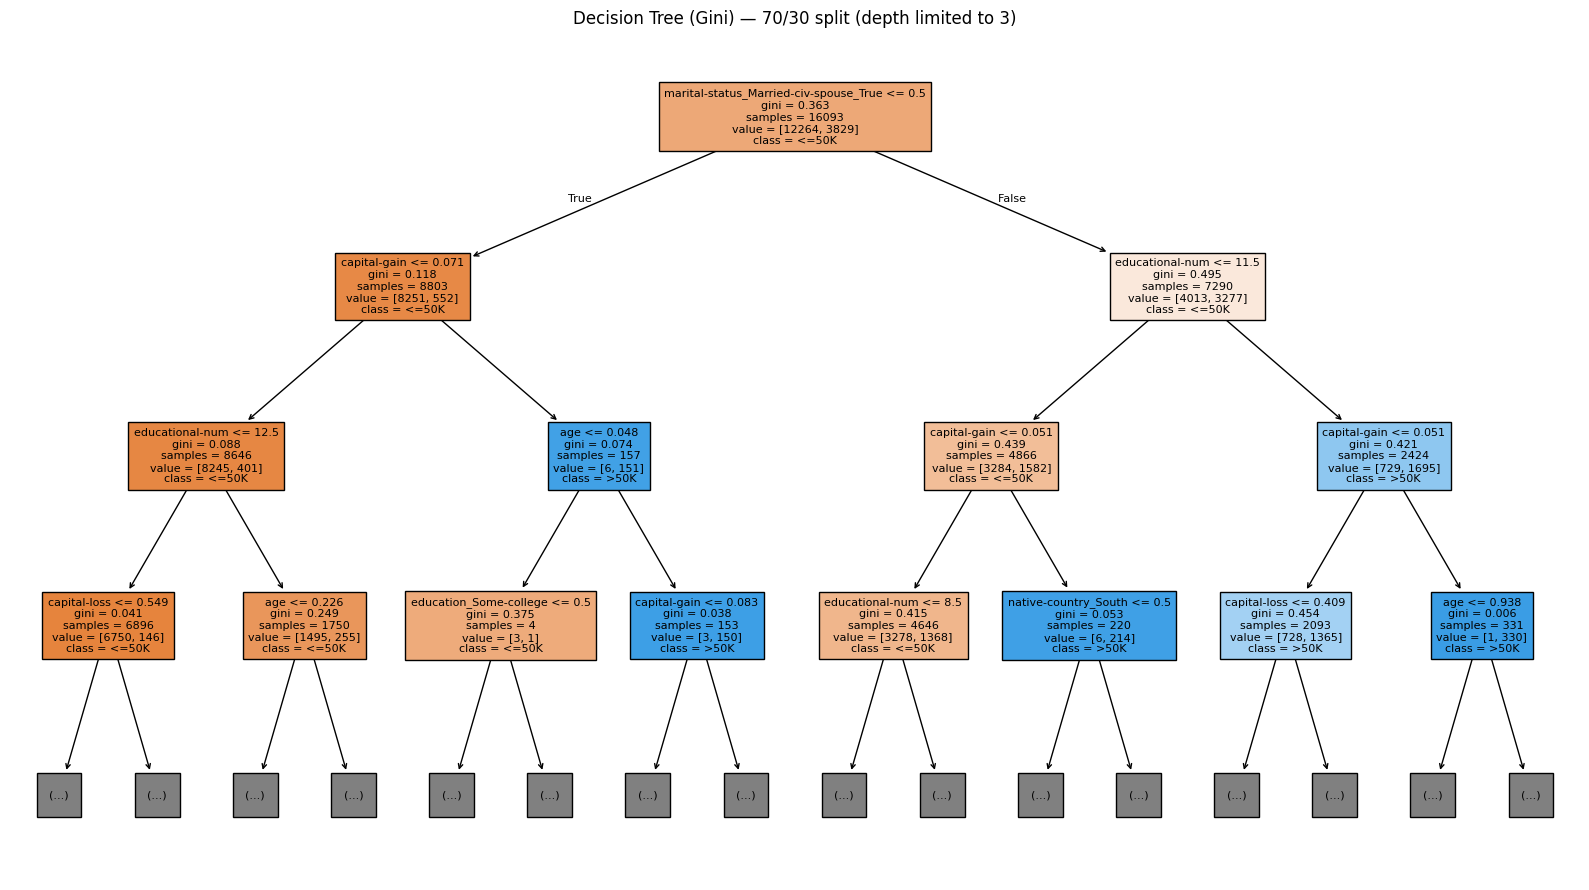

In [70]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

label_to_plot = "70/30"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

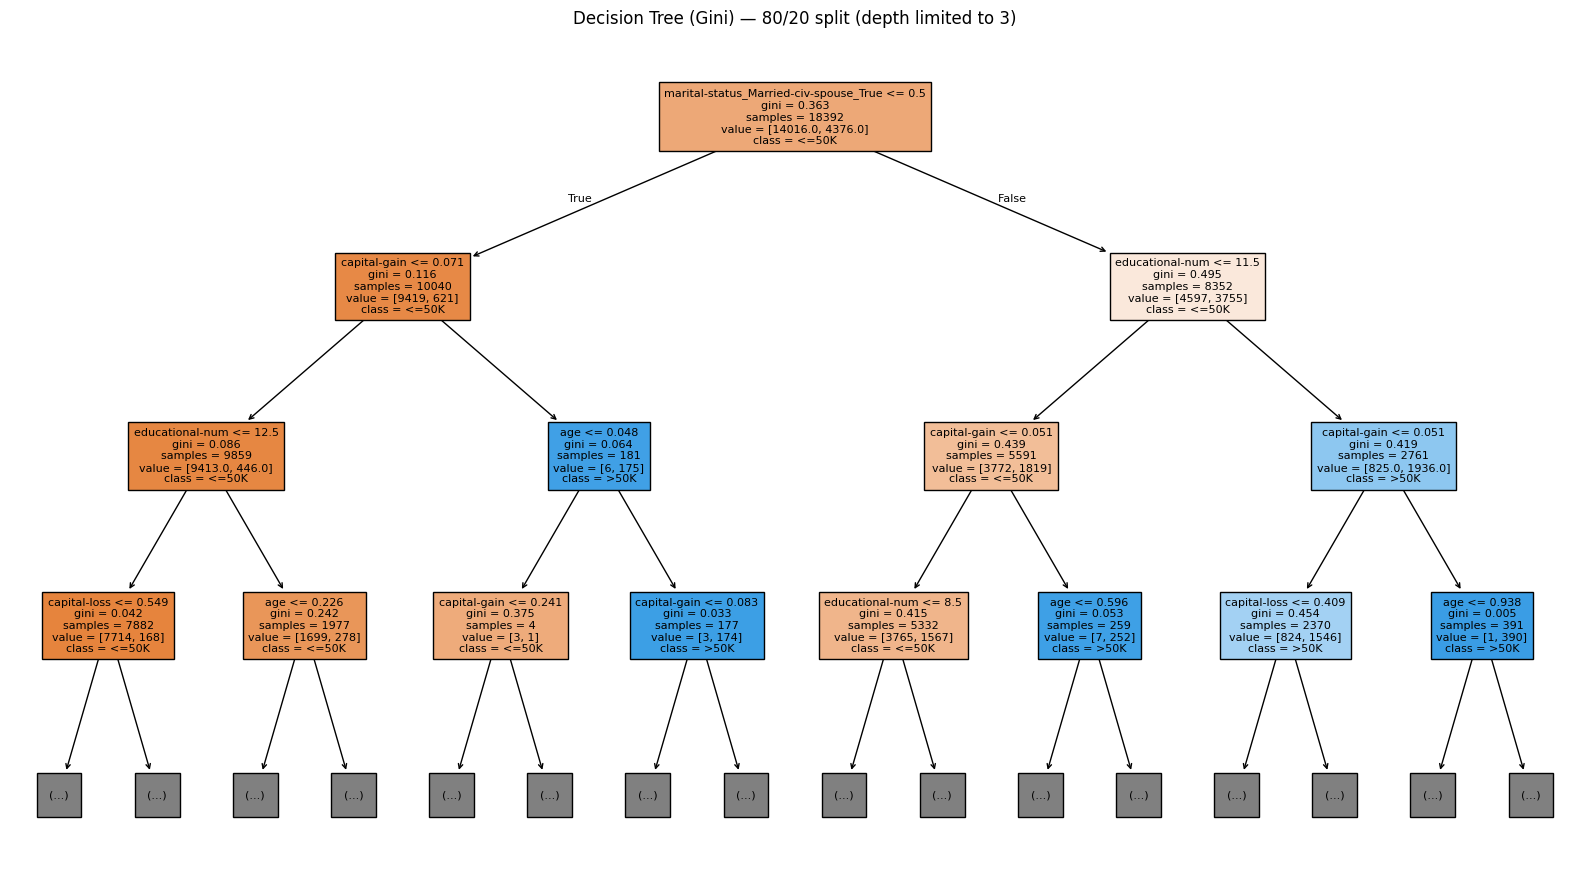

In [71]:
label_to_plot = "80/20"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

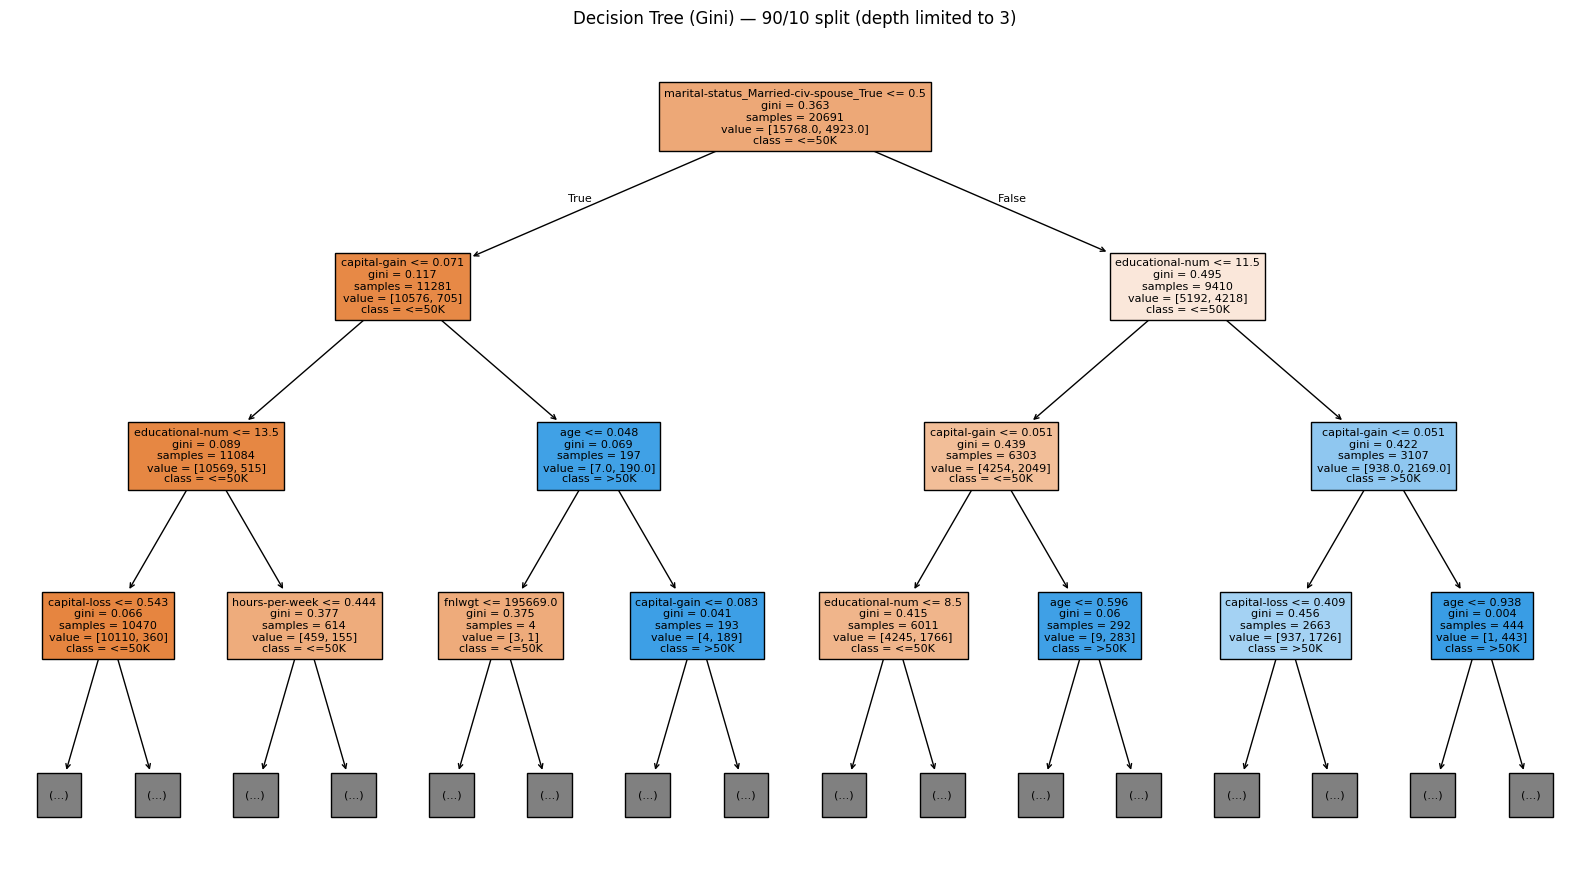

In [72]:
label_to_plot = "90/10"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

# **Comparison & Discussion**

The Decision Tree classifier using the Gini Index achieved consistent and reliable performance across all three data partitions.

**Performance Comparison**
- The highest accuracy (81.8%) was achieved with the 90/10 split, where more data was used for training.
- As expected, accuracy slightly decreased with larger test sizes (80/20 → 80.3%, 70/30 → 80.6%), which is normal since the model has fewer training samples.
- The similarity between precision, recall, and F1 across all splits indicates balanced classification performance — the model is not heavily biased toward one income class.
- The stability of results suggests that the Decision Tree generalizes well and does not overfit severely despite being trained on different data proportions.

**Confusion Matrix Interpretation**
- The confusion matrices show that the model correctly classifies a majority of low-income (≤50K) individuals (top-left cell) with some misclassification of high-income (>50K) as low-income (bottom-left cell).
- For example, in the 80/20 split:
1) 3,024 people earning ≤50K were correctly classified, while 482 were incorrectly labeled as >50K.

2) 756 high-income individuals were correctly identified, but 445 were misclassified.
- This pattern reveals a class imbalance effect — the dataset contains more low-income samples, making the model slightly better at recognizing that class.
- Still, the reasonable F1-scores (~0.81) confirm the model handles both classes fairly well.

**Visual Representation and Feature Insights**

From the decision tree visualizations (depth limited to 3), the most influential features are:
- Marital status (Married-civ-spouse) — the primary splitting feature, strongly associated with income level.
- Capital gain, education level, and occupation — secondary predictors that refine income classification.
- Individuals with higher capital gain and education level tend to belong to the >50K class, while those with lower values and “non-married” marital status are often in the ≤50K class.

The visual structure of the tree clearly reflects human-interpretable decision logic, demonstrating why Decision Trees are useful for exploratory analysis and transparent model behavior.

**Overall Interpretation**
- The model’s performance is consistent across different splits, suggesting robustness.
- Slightly higher precision than recall indicates the classifier is cautious in labeling someone as high-income (fewer false positives).
- The main limitations arise from class imbalance and potential overfitting if the full-depth tree were used.
- Future improvements could include pruning, balancing classes, or using ensemble methods (Random Forest) for enhanced generalization.

# **Classification using Entropy**

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

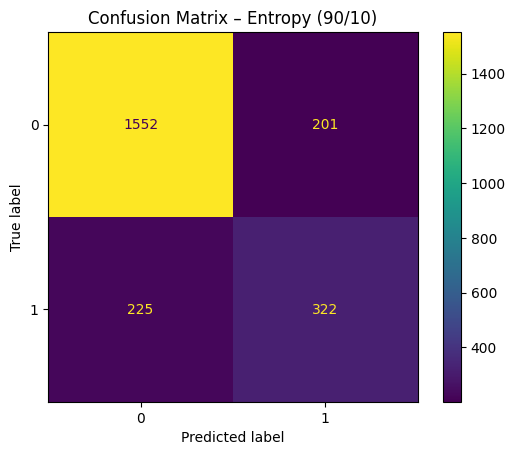

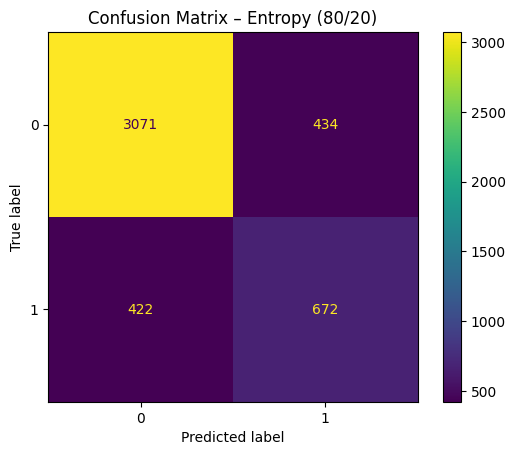

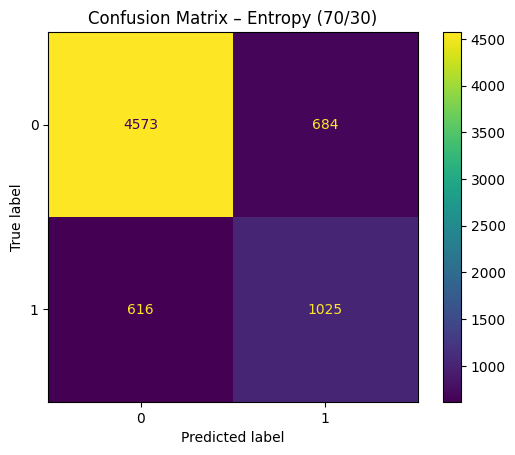

In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spilts = [(0.1, "90/10"), (0.2, "80/20"), (0.3, "70/30")]
results_entropy = []
trained_models_entropy = {}
for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=test_size, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
    plt.title(f"Confusion Matrix – Entropy ({label})")
    plt.show()

    results_entropy.append((label, acc, prec, rec, f1))
    trained_models_entropy[label] = (clf, X_test, y_test, y_pred)

# **Entropy Results Table**

In [75]:
import pandas as pd
results_df_entropy = pd.DataFrame(results_entropy, columns=["Split", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df_entropy

,Split,Accuracy,Precision,Recall,F1-Score
0,90/10,0.814783,0.812094,0.814783,0.813335
1,80/20,0.813873,0.814581,0.813873,0.814221
2,70/30,0.811540,0.814315,0.811540,0.812839


# **Comparison: Gini vs. Entropy**

,spilts,Gini Accuracy,Entropy Accuracy
0,90/10,0.814783,0.814783
1,80/20,0.812350,0.813873
2,70/30,0.810380,0.811540


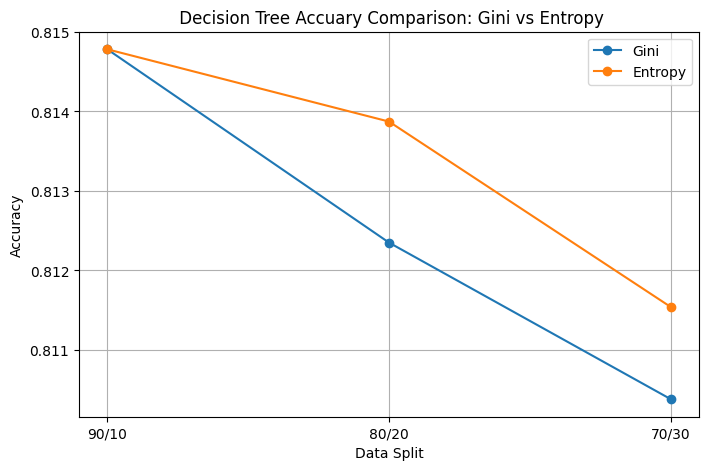

In [76]:
results_compare = pd.DataFrame({"spilts" : ["90/10", "80/20" , "70/30"] , "Gini Accuracy"
        : [0.814783,0.81235,0.810380], "Entropy Accuracy": results_df_entropy ["Accuracy"]})
display(results_compare)
plt.figure(figsize=(8, 5))
plt.plot(results_compare["spilts"],results_compare["Gini Accuracy"], marker='o', label="Gini")
plt.plot(results_compare["spilts"],results_compare["Entropy Accuracy"], marker='o', label="Entropy")
plt.title(" Decision Tree Accuary Comparison: Gini vs Entropy")
plt.xlabel("Data Split")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# **Discussion**

The Entropy-based Decision Tree achieved slightly higher accuracy across all splits compared to the Gini model.  
This indicates that Information Gain produced more informative splits, especially in categorical features.  
Both models maintained balanced precision and recall, meaning neither overfitted.  
However, Gini computed faster, while Entropy provided marginally better accuracy.